In [3]:
import pickle

with open("transcripts_and_texts.pickle", "rb") as f:
    full_data = pickle.load(f)

In [29]:
import polars as pl
joined_text = (
    full_data

    .filter(pl.col("index") != "intro")

    .with_columns(
        pl.col("index").str.replace(r"\d", "").alias("id"),
        pl.col("speech").str.replace("mmm", "").str.replace("Mmm", "").alias("speech")
    )

    .with_columns(
        pl.when(pl.col("id").str.to_lowercase().str.contains("story"))
        .then(pl.lit("story"))
        .otherwise(pl.lit("poem")).alias("genre"),
        pl.when(pl.col("id").str.to_lowercase().str.contains("discussion"))
        .then(pl.lit("discussion"))
        .otherwise(pl.lit("reading")).alias("event_type")
    )
    .group_by("session", "genre", "event_type")
    .agg(pl.col("speech").str.join(" "))
).with_row_index()
    

In [30]:
import spacy
nlp = spacy.load('en_core_web_sm')

tokens = []
for text in nlp.pipe(joined_text["speech"]):
    token = [token.lemma_.lower() for token in text if token.is_alpha and not token.is_stop]
    tokens.append(token)
tokens = pl.Series("tokens", tokens)

In [16]:
token_df = joined_text.insert_column(4, tokens)

In [17]:
from gensim.corpora.dictionary import Dictionary

dictionary = Dictionary(token_df["tokens"])
print(dictionary.token2id)


{'able': 0, 'acceleration': 1, 'accommodation': 2, 'account': 3, 'actually': 4, 'addict': 5, 'addicted': 6, 'addiction': 7, 'adequate': 8, 'advantage': 9, 'age': 10, 'ago': 11, 'agony': 12, 'ah': 13, 'aim': 14, 'aisle': 15, 'aloud': 16, 'amuse': 17, 'analogy': 18, 'answer': 19, 'anticipate': 20, 'anymore': 21, 'appear': 22, 'aspect': 23, 'aspiration': 24, 'aspire': 25, 'attention': 26, 'attitude': 27, 'away': 28, 'awful': 29, 'baby': 30, 'babysit': 31, 'background': 32, 'bad': 33, 'barely': 34, 'basically': 35, 'bat': 36, 'bear': 37, 'beautiful': 38, 'beautifully': 39, 'beauty': 40, 'beginning': 41, 'big': 42, 'birthday': 43, 'bit': 44, 'black': 45, 'blanket': 46, 'bored': 47, 'boring': 48, 'bottle': 49, 'break': 50, 'brief': 51, 'briefly': 52, 'bring': 53, 'burden': 54, 'busy': 55, 'buy': 56, 'call': 57, 'care': 58, 'carry': 59, 'cause': 60, 'celebrity': 61, 'cent': 62, 'certainty': 63, 'change': 64, 'character': 65, 'cheat': 66, 'checkout': 67, 'child': 68, 'childcare': 69, 'choice':

In [31]:
dictionary.filter_extremes(no_below=5, no_above=0.5)

In [32]:
corpus = [dictionary.doc2bow(doc) for doc in token_df['tokens']]


In [33]:
from gensim.models import LdaMulticore
from gensim.models import CoherenceModel
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, iterations=50, num_topics=10, workers = 4, passes=10)


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import pyLDAvis.gensim_models

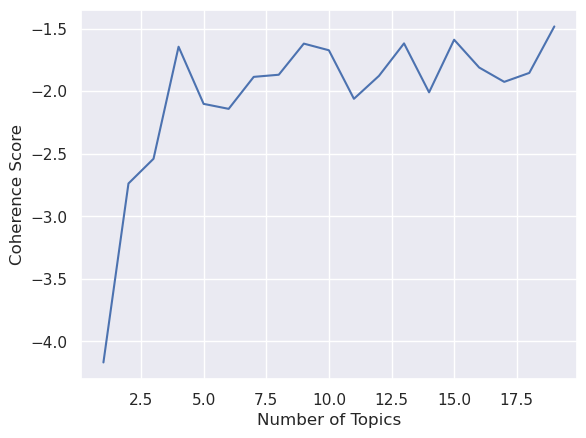

In [35]:
topics = []
score = []
for i in range(1,20,1):
   lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, iterations=10, num_topics=i, workers = 4, passes=10, random_state=100)
   cm = CoherenceModel(model=lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
   topics.append(i)
   score.append(cm.get_coherence())
_=plt.plot(topics, score)
_=plt.xlabel('Number of Topics')
_=plt.ylabel('Coherence Score')
plt.show()

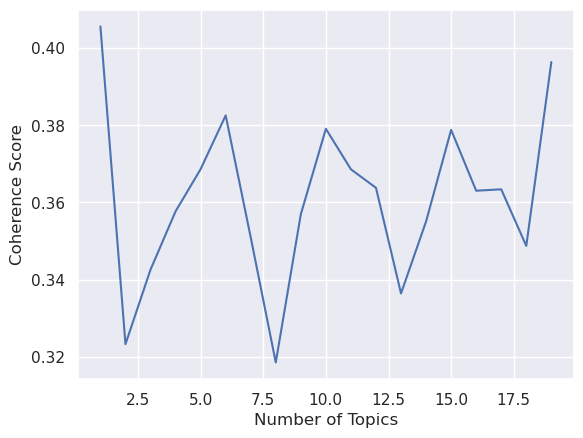

In [36]:
topics = []
score = []
for i in range(1,20,1):
   lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, iterations=10, num_topics=i, workers = 4, passes=10, random_state=100)
   cm = CoherenceModel(model=lda_model, texts = token_df['tokens'], corpus=corpus, dictionary=dictionary, coherence='c_v')
   topics.append(i)
   score.append(cm.get_coherence())
_=plt.plot(topics, score)
_=plt.xlabel('Number of Topics')
_=plt.ylabel('Coherence Score')
plt.show()

In [37]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, iterations=100, num_topics=5, workers = 4, passes=100)


In [38]:
lda_model.print_topics(-1)


[(0,
  '0.064*"mmm" + 0.034*"wendy" + 0.031*"doctor" + 0.021*"money" + 0.018*"slow" + 0.017*"ok" + 0.016*"pay" + 0.013*"heart" + 0.013*"breath" + 0.012*"buy"'),
 (1,
  '0.050*"open" + 0.016*"wild" + 0.016*"hm" + 0.016*"pretty" + 0.015*"parent" + 0.014*"geese" + 0.014*"desert" + 0.014*"trust" + 0.012*"adult" + 0.012*"dress"'),
 (2,
  '0.042*"mmm" + 0.030*"teacher" + 0.019*"village" + 0.019*"ok" + 0.016*"pause" + 0.016*"stone" + 0.014*"force" + 0.014*"father" + 0.014*"pain" + 0.014*"tomorrow"'),
 (3,
  '0.055*"sea" + 0.027*"rock" + 0.024*"tale" + 0.019*"fish" + 0.018*"night" + 0.018*"boy" + 0.017*"mountain" + 0.015*"annie" + 0.014*"foot" + 0.014*"river"'),
 (4,
  '0.088*"dog" + 0.023*"parent" + 0.022*"adult" + 0.019*"darkness" + 0.018*"mom" + 0.017*"hm" + 0.016*"hide" + 0.013*"beach" + 0.011*"fat" + 0.011*"fish"')]

In [39]:
token_df["speech"][0]


'I\'m  going to pause there for a bit. Hmm.  It definitely feels like an analogy for addiction because she\'s just gone and found another place to go and get it. Yeah. Like [UH] she just decided to go to a different doctor and pretend that she had no idea what was going on. She really needed it. Yes.  [UM] yeah, thinking a bit about how she\'s sort of making these decisions [UM] and the kind of thought process she\'s going through. [UM].  Because it starts off when she\'s when they\'re at the pub Mm. [UM] watching the football. Yeah. And she notices [UM]  Yeah, just that she reckons the players have kind of got an advantage, doesn\'t she? And that that and that kind of triggered her to think [UM] Cause the doctor had told her that people were buying the time. Yes. She\'s now thinking about who is buying the time? Yeah. Just by watching them. Yeah.  Yeah.  Is there anything we can do? Are you ok? She\'d had this cough for ages. Yeah have some more water as well. Yeah.  So when so like w

In [40]:
lda_model[corpus][0]

[(0, np.float32(0.99802136))]

In [41]:
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(lda_display)


In [59]:
topics = pl.Series("topics", [sorted(lda_model[corpus][text])[0][0] for text in range(len(token_df['speech']))]
)

In [60]:
token_df = token_df.insert_column(5, topics)